In [ ]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import torch

from vision_base.utils.builder import build
from vision_base.data.datasets.dataset_utils import collate_fn
from vision_base.utils.utils import cfg_from_file

print('CUDA available: {}'.format(torch.cuda.is_available()))


cfg = cfg_from_file("../configs/fisheye_kitti360.py")                 
is_test_train = True

# checkpoint path
checkpoint_name = "../workdirs/fisheye-test-0331/checkpoint/monodepth.networks.models.meta_archs.monodepth2_model.MonoDepthWPose_latest.pth"


CUDA available: True


In [50]:
index = 0
split_to_test='val'
cfg.train_dataset.augmentation = cfg.val_dataset.augmentation
is_test_train = split_to_test == 'training'
if split_to_test == 'training':
    dataset = build(**cfg.train_dataset)
elif split_to_test == 'test':
    dataset = build(**cfg.test_dataset)
else:
    dataset = build(**cfg.val_dataset)


meta_arch = build(**cfg.meta_arch)
meta_arch = meta_arch.cuda()

weight_path = checkpoint_name
state_dict = torch.load(weight_path, map_location='cuda:{}'.format(cfg.trainer.gpu))

meta_arch.load_state_dict(state_dict['model_state_dict'])
meta_arch.eval();

test_hook = build(**cfg.trainer.evaluate_hook.test_run_hook_cfg)

<ipython-input-50-6f53fb385178>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location='cuda:{}'.format(cfg.trainer.gpu))


In [51]:
def denorm(image):
    new_image = np.clip((image * cfg.data.augmentation.rgb_std +  cfg.data.augmentation.rgb_mean) * 255, 0, 255)
    new_image = np.array(new_image, dtype=np.uint8)
    return new_image

from numba import jit
@jit(cache=False, nopython=True)
def ToColorDepth(depth_image:np.ndarray)->np.ndarray: #[H, W] -> [H, W, 3]
    H, W = depth_image.shape
    max_depth = float(np.max(depth_image))
    cmap = np.array([
        [0,0,0,114],[0,0,1,185],[1,0,0,114],[1,0,1,174], 
        [0,1,0,114],[0,1,1,185],[1,1,0,114],[1,1,1,0]
    ])
    _sum  = 0
    for i in range(8):
        _sum += cmap[i, 3]
    
    weights = np.zeros(8)
    cumsum = np.zeros(8)
    for i in range(7):
        weights[i] = _sum / cmap[i, 3]
        cumsum[i+1] = cumsum[i] + cmap[i, 3] / _sum
    
    image = np.zeros((H, W, 3), dtype=np.uint8)
    for i in range(H):
        for j in range(W):
            val = depth_image[i, j] / max_depth
            for k in range(7):
                if val <= cumsum[k + 1]:
                    break
            w = 1.0- (val - cumsum[k]) * weights[k]
            r = int( (w * cmap[k, 0] + (1 - w) * cmap[k+1, 0]) * 255 )
            g = int( (w * cmap[k, 1] + (1 - w) * cmap[k+1, 1]) * 255 )
            b = int( (w * cmap[k, 2] + (1 - w) * cmap[k+1, 2]) * 255 )
            image[i, j] = np.array([r,g,b])
    return image


In [ ]:
def compute_once(index):
    data = dataset[index]


    h_eff, w_eff = data[('image_resize', 'effective_size')]
    collated_data = collate_fn([data])


    image = collated_data[('image', 0)]
    rgb_image = denorm(image[0].cpu().numpy().transpose([1, 2, 0]))
    with torch.no_grad():
        output_dict = test_hook(collated_data, meta_arch)
        # depth = output_dict["depth"][0, 0]
        depth = output_dict["norm"][0, 0] ##gy## norm or depth vis
        print(depth.max(), depth.min())
        depth_uint16 = (depth * 256).cpu().numpy().astype(np.uint16)
        color_depth = ToColorDepth(depth_uint16)
       
    plt.subplot(2, 2, 1)
    
    plt.imshow(np.clip(rgb_image, 0, 255)[0:h_eff, 0:w_eff])
    plt.axis('off')
    plt.subplot(2, 2, 2)
    plt.imshow( 1 / (depth_uint16 / 256)[0:h_eff, 0:w_eff], cmap='magma', vmin=1.0/(70), vmax= 1 / max(depth_uint16.min()/256, 2.0) )
    plt.axis('off')
    
    plt.subplot(2, 2, 3)
    color_depth = ToColorDepth(depth_uint16)
    plt.imshow(depth_uint16[0:h_eff, 0:w_eff] / 256)
    plt.axis('off')
    plt.subplot(2, 2, 4)
    alpha = 0.3
    masked = (alpha * color_depth + (1 - alpha) * rgb_image).astype(np.uint8)
    plt.imshow(masked[0:h_eff, 0:w_eff])
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return np.clip(rgb_image, 0, 255), color_depth, depth_uint16



986
tensor(127.2322, device='cuda:0') tensor(2.2681, device='cuda:0')


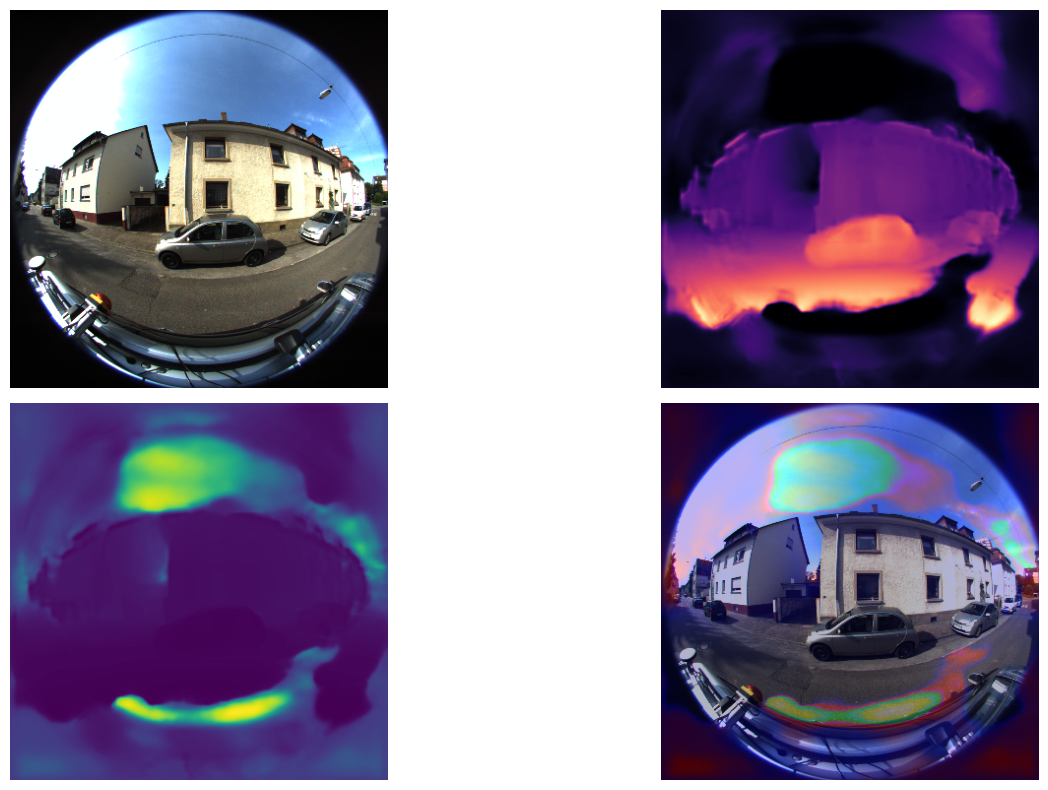

In [54]:
%matplotlib inline
index = np.random.randint(0, len(dataset))
# index = 0
print(len(dataset))
fig = plt.figure(figsize=(16, 8))

rgb_image, color_depth, depth_uint16  = compute_once(index);


###gy## 保存地址 /data/fisheye_campus/0517_depth_results